In [1]:
%load_ext autoreload
%autoreload 2
%cd ../../..
from rich import print



/Volumes/CrucialX/project-equinox


In [2]:
case_dir = "data/cases/LGAV_LFPG/"
batch_sgd_results_dir_path = f"{case_dir}batch_sgd_results/"

In [3]:
# Look for the latest checkpoint in the `batch_sgd_results_dir_path`
import re
from pathlib import Path

def get_latest_checkpoint(results_dir_path):
    directory = Path(results_dir_path)
    
    # Pattern to match 'checkpoint_iter_X.pt' and capture X
    pattern = re.compile(r"checkpoint_iter_(\d+)\.pt")
    
    checkpoints = []
    
    # Iterate through files in the directory
    for file in directory.glob("checkpoint_iter_*.pt"):
        match = pattern.search(file.name)
        if match:
            iteration = int(match.group(1))
            checkpoints.append((iteration, file.name))
            
    if not checkpoints:
        return None
    
    # Sort by the iteration number (the first element of the tuple) and get the last one
    latest_checkpoint = max(checkpoints, key=lambda x: x[0])
    
    return latest_checkpoint[1]


latest_checkpoint_filename = batch_sgd_results_dir_path + get_latest_checkpoint(batch_sgd_results_dir_path)
print(f"Latest checkpoint: {latest_checkpoint_filename}")

Latest checkpoint: data/cases/LGAV_LFPG/batch_sgd_results/checkpoint_iter_250.pt

In [4]:
from equinox.posttrain import load_cost_model_parameters
from rich.console import Console
from rich.table import Table

def print_params_table(params_dict):
    console = Console()
    
    # Initialize the table
    table = Table(title="Common Parameters", show_header=True, header_style="bold magenta")
    
    table.add_column("Parameter", style="dim", width=12)
    table.add_column("Value", justify="right")

    # Add rows, formatting floats to 6 decimal places for clarity
    for key, value in params_dict.items():
        table.add_row(key, f"{value:.6f}")

    console.print(table)

params = load_cost_model_parameters(latest_checkpoint_filename)
print("[bold red]Parameters retrieved from learned cost model[/bold red]")
print_params_table(params["common"])
print(params["preference_matrix"].shape)  # (num_nodes, num_nodes)

Parameters retrieved from learned cost model

     Common Parameters     
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Parameter    ┃    Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ bias         │ 0.050271 │
│ ac_dist      │ 0.000124 │
│ time         │ 0.015495 │
└──────────────┴──────────┘

torch.Size([600, 600])

Loading route graph from /Volumes/CrucialX/project-equinox/data/cases/LGAV_LFPG/graphs/routes.gml

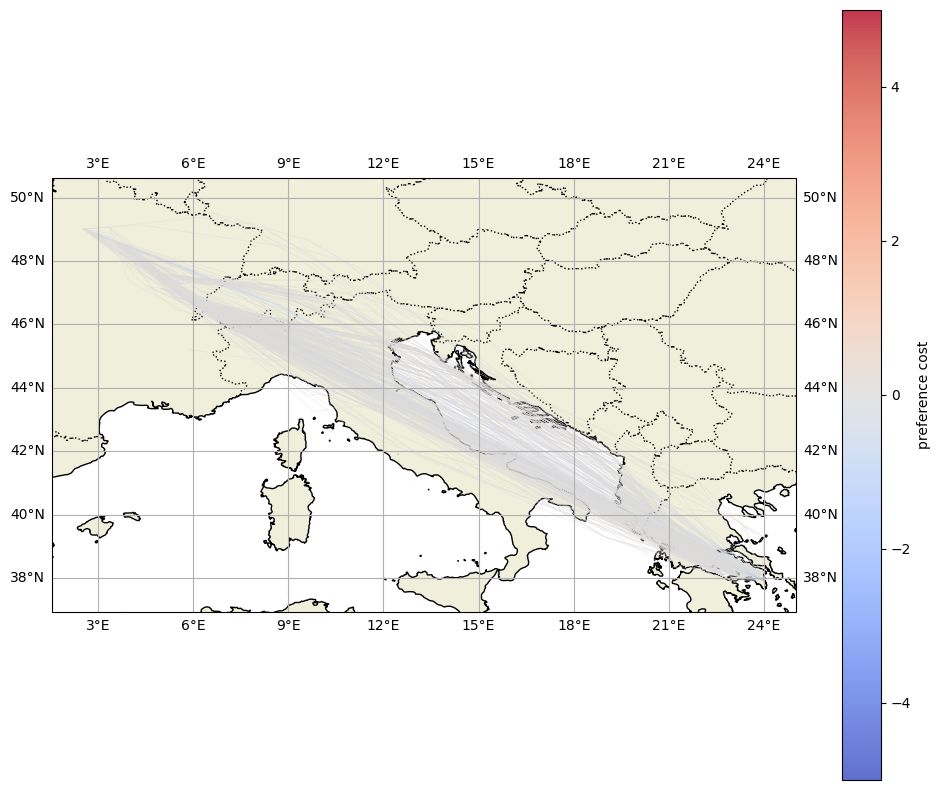

<GeoAxes: >

In [5]:
from equinox.posttrain import load_checkpoint_edge_preferences, plot_edge_preferences_cartopy

from pathlib import Path

def get_gml_path(batch_sgd_results_dir_path: str) -> str:
    """
    Recursively searches for a .gml file in the specified directory.
    Returns the absolute path to the .gml file.
    """
    directory = Path(batch_sgd_results_dir_path)
    
    # rglob("*.gml") searches recursively for all files ending in .gml
    # We use next() to get the first result since only one is guaranteed.
    try:
        gml_file = next(directory.rglob("*.gml"))
        return str(gml_file.absolute())
    except StopIteration:
        raise FileNotFoundError(f"No .gml file found in {batch_sgd_results_dir_path}")

gml_path = get_gml_path(case_dir)
print(f'Loading route graph from {gml_path}')

payload = load_checkpoint_edge_preferences(latest_checkpoint_filename, gml_path)
plot_edge_preferences_cartopy(
    payload["graph"],
    edge_preferences=payload["edge_preferences"],
    cmap="coolwarm",
    linewidth=0.3,
    alpha=0.8,
    percentile=0.5,
    percentile_mode="upper", # upper = more preferred, lower = less preferred, contrast = half lowest, half highest
    preference_color_range=(-5,5)
)

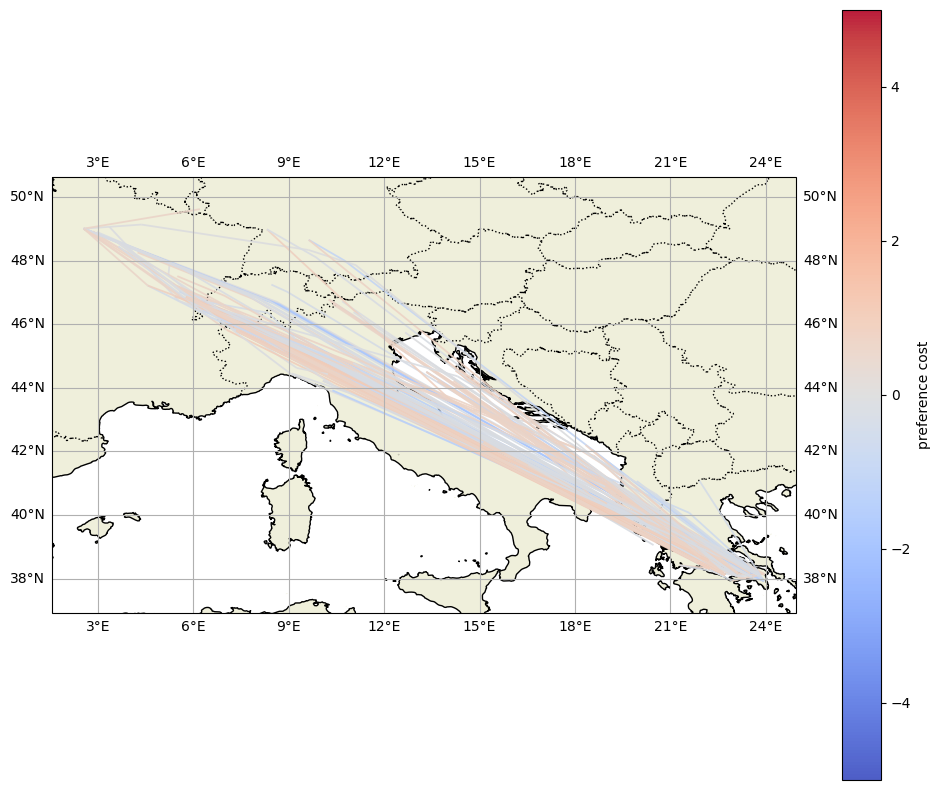

<GeoAxes: >

In [13]:
plot_edge_preferences_cartopy(
    payload["graph"],
    edge_preferences=payload["edge_preferences"],
    cmap="coolwarm",
    linewidth=1.3,
    alpha=0.9,
    percentile=0.1,
    percentile_mode="contrast", # upper = more preferred, lower = less preferred, contrast = half lowest, half highest
    preference_color_range=(-5,5)
)

# Route cost decomposition and inspection

In [7]:
from equinox.posttrain.cost_back_envelope import compute_route_cost_breakdown, breakdown_to_frame

result = compute_route_cost_breakdown(
    checkpoint_path=latest_checkpoint_filename,
    case_dir=case_dir,
    flight_id="468E45SEH9AP",
    takeoff_time="1680509230"
)

df = breakdown_to_frame(result["breakdown"])
print_params_table(result["totals"])
print(df.head())


All components initialized successfully:
  - Graph loaded with 600 nodes
  - Origin: LGAV (idx: 185)
  - Goal: LFPG (idx: 376)
  - Device: cpu
  - Distance matrix shape: (600, 600)
  - Charges matrix shape: (600, 600)


     Common Parameters     
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Parameter    ┃    Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ cost_bias    │ 0.351899 │
│ cost_ac_dist │ 0.098552 │
│ cost_time    │ 2.403397 │
│ cost_prefer… │ 0.583062 │
│ cost_common  │ 2.853848 │
│ cost_total   │ 3.436910 │
└──────────────┴──────────┘

u_node v_node  u_idx  v_idx    distance  airspace_charge  tailwind_kts  \
0   LGAV   LGMG    185    125   27.511467        25.460000     -5.536989   
1   LGMG  UNKIR    125    555  941.566390        67.498185      0.000000   
2  UNKIR   LFET    555     29   48.672278        80.070000    -24.403259   
3   LFET  WERZU     29    374   89.360347        80.071898      0.000000   
4  WERZU   LFPE    374     50   36.750706        80.070000      0.000000   

   tailwind_is_fallback  feature_bias  feature_ac_dist  feature_time  \
0                 False           1.0         7.004420      3.713893   
1                  True           1.0       635.540227    125.542185   
2                 False           1.0        38.971893      6.861746   
3                  True           1.0        71.552526     11.914713   
4                  True           1.0        29.426291      4.900094   

   weight_bias  weight_ac_dist  weight_time  cost_bias  cost_ac_dist  \
0     0.050271        0.000124     0.015495   0.050271      0.000868   
1     0.050271        0.000124     0.015495   0.050271      0.078727   
2     0.050271        0.000124     0.015495   0.050271      0.004828   
3     0.050271        0.000124     0.015495   0.050271      0.008864   
4     0.050271        0.000124     0.015495   0.050271      0.003645   

   cost_time  cost_preference  cost_common  cost_total  
0   0.057546        -0.020524     0.108685    0.088161  
1   1.945239         0.078391     2.074237    2.152628  
2   0.106321         0.207343     0.161420    0.368763  
3   0.184615        -0.029035     0.243750    0.214715  
4   0.075925        -0.029035     0.129842    0.100807

# Inference/Sampling

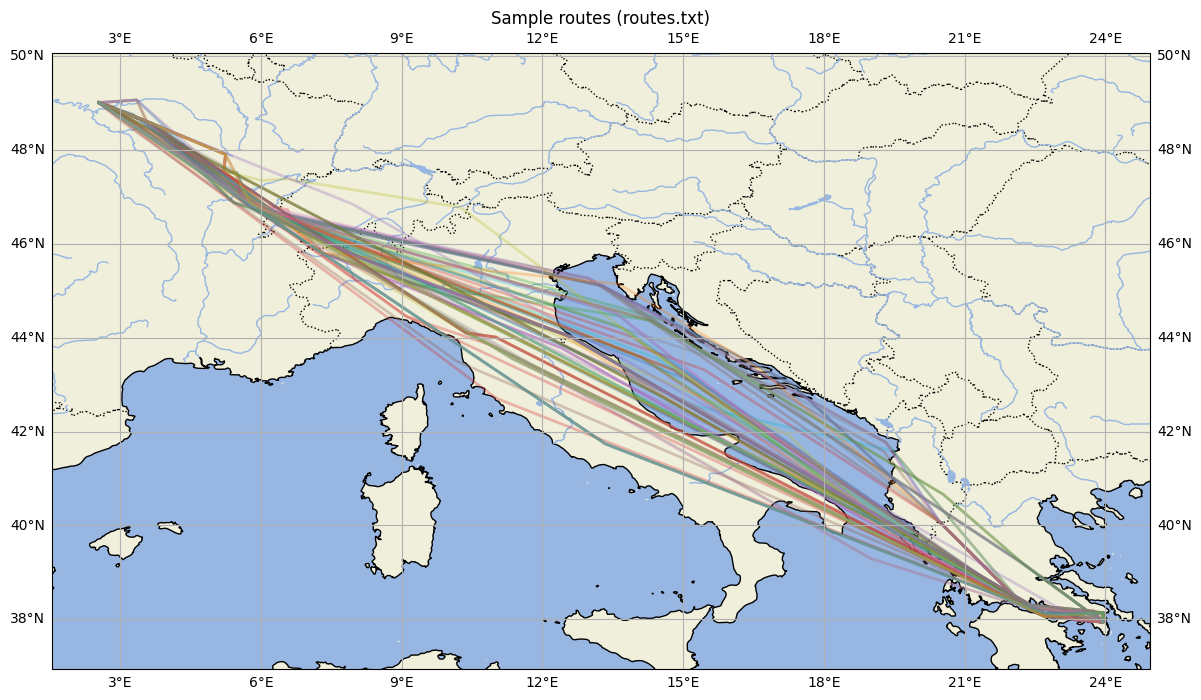

(<Figure size 1800x800 with 1 Axes>,
 <GeoAxes: title={'center': 'Sample routes (routes.txt)'}>)

In [12]:
from src.equinox.posttrain.plot_sample_routes import plot_sample_routes
from pathlib import Path 

plot_sample_routes(
        case_dir=Path(case_dir),
        routes_path=Path("data/cases/LGAV_LFPG/inference_outputs/sample_100/routes.txt"),
        show=True,
        show_waypoints=False,
        route_alpha=0.3
    )